### 2a) Finding the best time of day and day of week to minimise delays

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker


In [2]:
# Reading the data & combining the years data into flights_df dataframe
years = range(2004, 2009)
file_names = [f"{year}.csv.bz2" for year in years]

# Load and concatenate flight data without filtering
chunks = []
for fname, year in zip(file_names, years):
    chunk = pd.read_csv(fname, low_memory = False).assign(Year = year)
    chunks.append(chunk)

flights_df = pd.concat(chunks, ignore_index = True)


In [4]:
# Filtering the data for analysis
flights_filtered = flights_df[
    (flights_df['Cancelled'] == 0) &
    (flights_df['Diverted'] == 0) &
    (flights_df['DepTime'] < 2400) &
    (flights_df['ArrTime'] < 2400)
]


In [5]:
# Droping unnecessary columns from the dataset
cols_to_drop = ['TaxiIn', 'TaxiOut', 'CancellationCode',
                'CarrierDelay', 'WeatherDelay', 'SecurityDelay', 'NasDelay', 'LateAircraftDelay']
flights_filtered = flights_filtered.drop(columns = cols_to_drop, errors = 'ignore')

In [6]:
# Convertung year to string for better readability
flights_filtered['Year'] = flights_filtered['Year'].astype(str)

In [ ]:
# Categorising the different delay groups
flights_filtered.loc[:, 'delay_category'] = np.select(
    [
        flights_filtered['ArrDelay'] < 0,
        flights_filtered['ArrDelay'] <= 15,
        (flights_filtered['ArrDelay'] > 15) & (flights_filtered['ArrDelay'] < 30),
        (flights_filtered['ArrDelay'] >= 30) & (flights_filtered['ArrDelay'] < 45),
        flights_filtered['ArrDelay'] >= 45
    ],
    ["Early", "On-Time", "Short Delay", "Medium Delay", "Long Delay"],
    default = None
)


In [7]:
# Define the order of delay categories
flights_filtered['delay_category'] = pd.Categorical(
    flights_filtered['delay_category'],
    categories = ["Early", "On-Time", "Short Delay", "Medium Delay", "Long Delay"],
    ordered = True
)

In [8]:
# Calculate delay percentages per year and category
delay_perc = flights_filtered.groupby(['Year', 'delay_category'], observed = True).size().reset_index(name='count')
delay_perc['percentage'] = delay_perc.groupby('Year')['count'].transform(lambda x: x / x.sum() * 100)

<Figure size 1800x600 with 0 Axes>

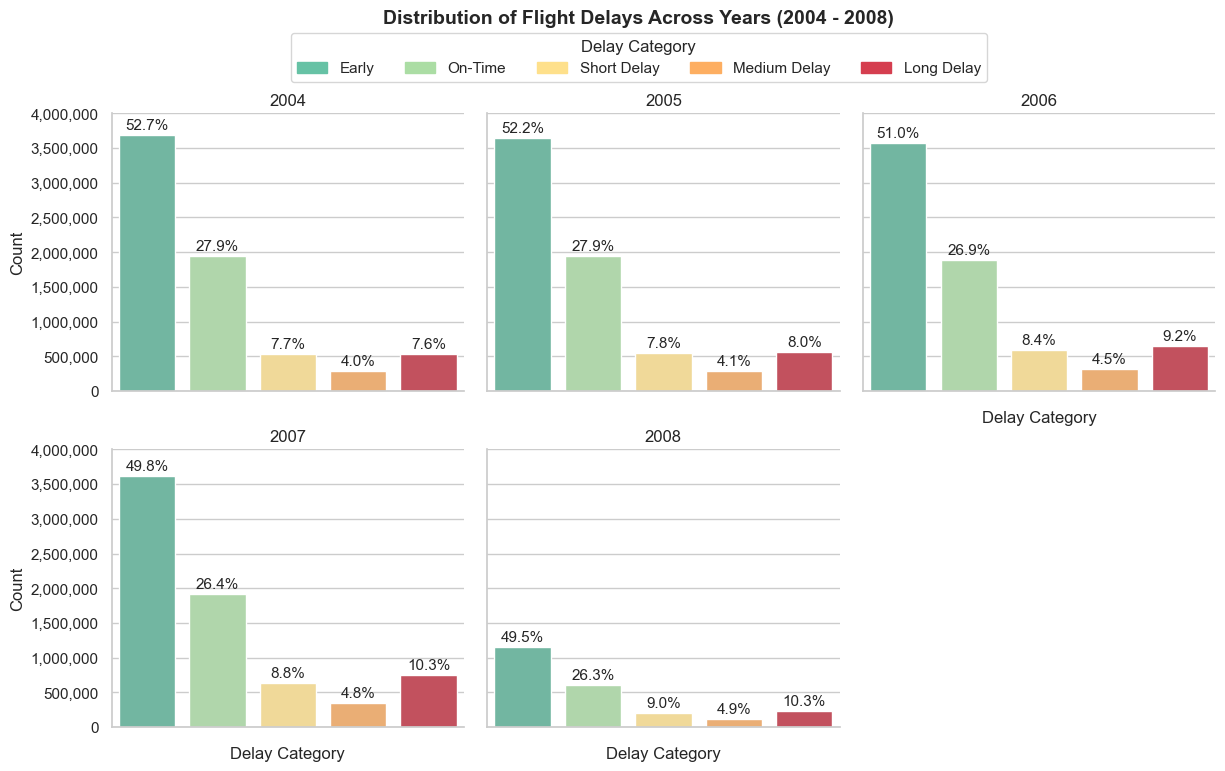

In [9]:
# Ploting faceted bar chart showing delay counts and percentages per year
plt.figure(figsize = (18, 6))
bar_palette = {
    "Early": "#66c2a5",
    "On-Time": "#abdda4",
    "Short Delay": "#fee08b",
    "Medium Delay": "#fdae61",
    "Long Delay": "#d53e4f"
}
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data = delay_perc,
    x = "delay_category", y = "count", hue = "delay_category",
    col = "Year", kind = "bar", col_wrap = 3,
    palette = bar_palette, height = 4, aspect = 1, legend = False
)
g.set_axis_labels("Delay Category", "Count")
g.set_titles("{col_name}")
g.set_xticklabels(rotation = 45, ha = 'right')

# Add percentage labels to each bar
for ax, (_, group) in zip(g.axes.flatten(), delay_perc.groupby("Year")):
    bars = ax.patches
    for i, bar in enumerate(bars):
        perc = group.iloc[i % len(group)]['percentage']
        ax.text(
                bar.get_x() + bar.get_width() / 2, 
                bar.get_height() + 40000,
                f"{perc:.1f}%", 
                ha = 'center', va = 'bottom', fontsize = 11
            )
for ax in g.axes.flatten():
    ax.set_ylim(0, 4000000)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.ticklabel_format(axis='y', style='plain')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Addiing Colour legends into bar chart
legend_patches = [mpatches.Patch(color = color, label = label) for label, color in bar_palette.items()]
g.fig.legend(handles = legend_patches, title = "Delay Category", loc = 'upper center', bbox_to_anchor = (0.5, 0.96), ncols = 5)

# Plotting the faceted bar chart
plt.subplots_adjust(top = 0.85)
g.fig.suptitle("Distribution of Flight Delays Across Years (2004 - 2008)", fontsize = 14, weight = 'bold')
plt.show()

In [ ]:
# Extracting hours from DepTime and ArrTime columns
flights_filtered["dep_hour"] = np.floor(flights_filtered["DepTime"] / 100)
flights_filtered["arr_hour"] = np.floor(flights_filtered["ArrTime"] / 100)

In [10]:
# Extract departure and arrival hours, and bin the departute hour into 3-hour groups
bins = [0, 3, 6, 9, 12, 15, 18, 21, 24]
labels = ["0-2", "3-5", "6-8", "9-11", "12-14", "15-17", "18-20", "21-23"]
flights_filtered['hr_grp'] = pd.cut(flights_filtered['dep_hour'], bins = bins, labels = labels, right = False, include_lowest = True)

# Convert numeric day of week to readable labels and reverse order for heatmap
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
flights_filtered['DayOfWeek'] = flights_filtered['DayOfWeek'].map(dict(zip(range(1, 8), day_labels)))
flights_filtered['DayOfWeek'] = pd.Categorical(flights_filtered['DayOfWeek'], categories = day_labels, ordered = True)
flights_filtered['hr_grp'] = pd.Categorical(flights_filtered['hr_grp'], categories = labels, ordered = True)


In [11]:
# Group by Year, DayOfWeek and hr_grp to get average arrival delays
arr_delay_heatmap = flights_filtered.groupby(['Year', 'DayOfWeek', 'hr_grp'], observed = True)['ArrDelay'].mean().reset_index(name = 'avg_arr_delay')

# Compute average delay per 3-hour block for each year
block_benchmark = flights_filtered.groupby(['Year', 'hr_grp'], observed = True)['ArrDelay'].mean().reset_index(name = 'block_average_delay')

# Compute overall block average for each year
overall_block_avg = block_benchmark.groupby('Year')['block_average_delay'].mean().reset_index()
overall_block_avg.rename(columns = {'block_average_delay': 'overall_delay'}, inplace = True)

# Add delay category for each 3-hour block based on benchmark values
block_coloured = block_benchmark.copy()
block_coloured['block_delay_category'] = pd.cut(
    block_coloured['block_average_delay'],
    bins = [-np.inf, 0, 15, 30, 45, np.inf],
    labels = ["Early", "On-Time", "Short Delay", "Medium Delay", "Long Delay"],
    right=False
)

In [13]:
# Display summary table of average delay for each hour group and year
for year in block_coloured['Year'].unique():
    year_data = block_coloured[block_coloured['Year'] == year].copy()
    year_data = year_data.sort_values(by='hr_grp')
    print(f"\nYear: {year}")
    overall = overall_block_avg[overall_block_avg['Year'] == year]['overall_delay'].values[0]
    print(f"Overall Block Avg Delay: {overall:.1f} mins")
    print(year_data[['hr_grp', 'block_average_delay', 'block_delay_category']].to_string(index = False))



Year: 2004
Overall Block Avg Delay: 12.3 mins
hr_grp  block_average_delay block_delay_category
   0-2            52.040885           Long Delay
   3-5            -5.525787                Early
   6-8            -1.307891                Early
  9-11             2.368363              On-Time
 12-14             5.026713              On-Time
 15-17             8.415991              On-Time
 18-20            13.440367              On-Time
 21-23            23.797728          Short Delay

Year: 2005
Overall Block Avg Delay: 13.7 mins
hr_grp  block_average_delay block_delay_category
   0-2            57.327124           Long Delay
   3-5            -4.818188                Early
   6-8            -1.264692                Early
  9-11             2.662029              On-Time
 12-14             5.440675              On-Time
 15-17             9.206787              On-Time
 18-20            14.399722              On-Time
 21-23            26.381858          Short Delay

Year: 2006
Overall Bloc

In [12]:
# Merge both averages and calculate the difference
arr_delay_heatmap = arr_delay_heatmap.merge(block_benchmark, on=['Year', 'hr_grp'])
arr_delay_heatmap['diff'] = arr_delay_heatmap['avg_arr_delay'] - arr_delay_heatmap['block_average_delay']

# Categorize delay class based on difference from block average
arr_delay_heatmap['delay_class'] = pd.cut(
    arr_delay_heatmap['diff'],
    bins = [-np.inf, -2, 2, np.inf],
    labels = ["Below Average", "Average", "Above Average"]
)

# Define color palette for the delay classes
delay_colours = {
    "Below Average": "#2ECC71",
    "Average": "#F4D03f",
    "Above Average": "#E74C3C"
}

In [ ]:
# Extracting and sorting uniquw years for plotting
years = sorted(arr_delay_heatmap['Year'].unique())

In [ ]:
# Determining the subplot layout based on no. of years
import math

n_years = len(years)
n_cols = 3
n_rows = math.ceil(n_years / n_cols)
days = list(arr_delay_heatmap["DayOfWeek"].cat.categories)
hours = list(arr_delay_heatmap["hr_grp"].cat.categories)

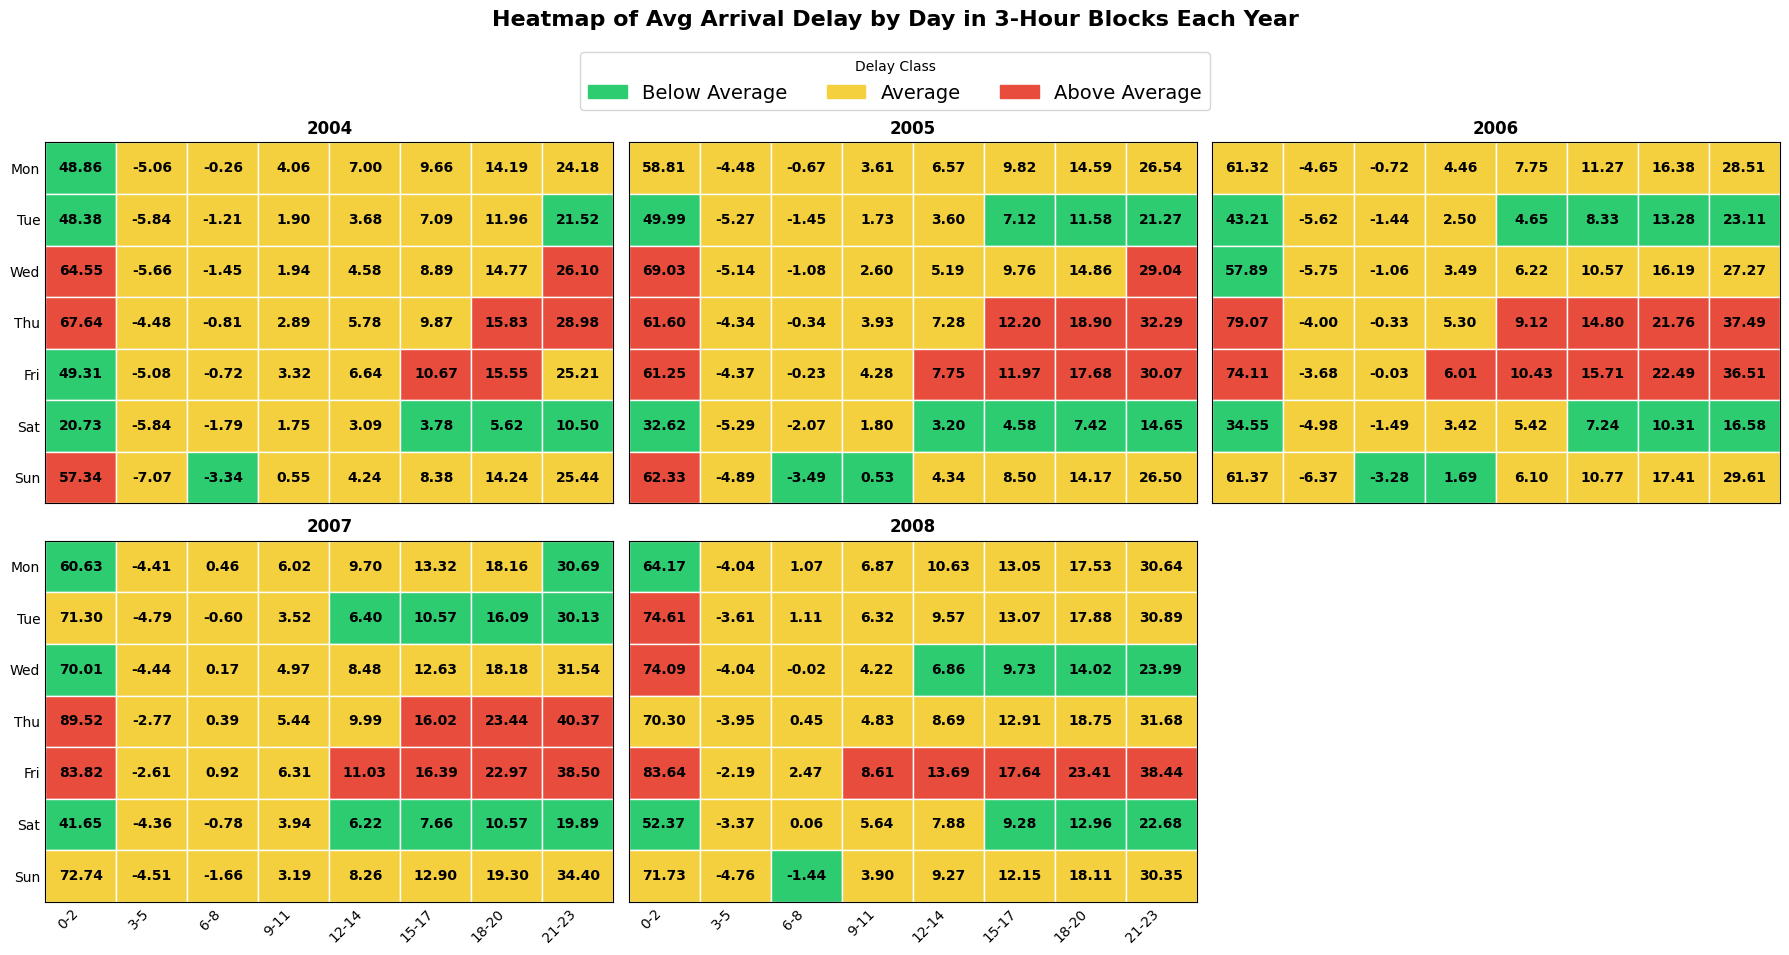

In [ ]:
import matplotlib.patches as mpatches

# Create subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize = (18, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Plot one heatmap per year
for i, year in enumerate(years):
    ax = axes[i]
    data = arr_delay_heatmap[arr_delay_heatmap['Year'] == year].copy()
    pivot_vals = data.pivot(index='DayOfWeek', columns='hr_grp', values='avg_arr_delay').reindex(index=days, columns=hours)
    pivot_class = data.pivot(index='DayOfWeek', columns='hr_grp', values='delay_class').reindex(index=days, columns=hours)

    for y_idx, day in enumerate(days):
        for x_idx, hr in enumerate(hours):
            val = pivot_vals.loc[day, hr]
            delay_class = pivot_class.loc[day, hr]
            if not pd.isna(val):
                color = delay_colours.get(delay_class, "#FFFFFF")
                ax.add_patch(plt.Rectangle((x_idx - 0.5, y_idx - 0.5), 1, 1, color=color, ec='white'))
                ax.text(x_idx, y_idx, f"{val:.2f}", ha = 'center', va = 'center', fontsize = 10, color = 'black', fontweight = 'bold')

    ax.set_title(f"{year}", fontsize = 12, weight = 'bold')
    ax.set_xticks(np.arange(len(hours)))
    ax.set_yticks(np.arange(len(days)))
    ax.set_xticklabels(hours, rotation = 45, ha = 'right')
    ax.set_yticklabels(days)
    ax.tick_params(axis = 'both', which = 'both', length = 0)
    ax.set_xlim(-0.5, len(hours) - 0.5)
    ax.set_ylim(len(days) - 0.5, -0.5)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add legend manually
legend_patches = [mpatches.Patch(color = color, label = label) for label, color in delay_colours.items()]
fig.legend(handles = legend_patches, title = "Delay Class", loc = 'lower center',bbox_to_anchor = (0.5, 0.87), ncol = 3, prop = {'size': 14})

# Title and layout
fig.suptitle("Heatmap of Avg Arrival Delay by Day in 3-Hour Blocks Each Year", fontsize = 16, weight='bold')
plt.tight_layout(rect = [0, 0.03, 1, 0.92])
plt.show()

### 2b) Evaluating if older planes suffer more delays on a yr-to-yr basis

In [7]:
# Importing libraries
from datetime import datetime
from matplotlib.ticker import FuncFormatter

In [8]:
# Reading the planes-data.csv data
planes_df = pd.read_csv("plane-data.csv", keep_default_na=False)

In [9]:
# Trimming empty spaces and conveerting blank strings to Na
str_cols = planes_df.select_dtypes(include='object').columns
planes_df[str_cols] = planes_df[str_cols].apply(lambda col: col.str.strip())
planes_df.replace('', np.nan, inplace=True)

In [10]:
# Removing rows with NaN values
planes_df.dropna(inplace=True)

In [11]:
# Removing rows with NA issue dates
planes_df.loc[planes_df['year'].isin(['None', '0000']), 'year'] = np.nan
planes_df['year'] = pd.to_numeric(planes_df['year'], errors='coerce')
planes_df = planes_df[
    (planes_df['issue_date'] != 'None') &
    (planes_df['year'].notna())
]

In [12]:
# Converting issue_date to datetime format, year to numeric & renaming tailnum to TailNum
planes_df['issue_date'] = pd.to_datetime(planes_df['issue_date'], format="%m/%d/%Y", errors='coerce')
planes_df = planes_df.rename(columns = {'tailnum': 'TailNum'})

In [13]:
# Merging flights_filtered and planes_df by TailNum and selecting only tailNUm and issue_date columns
flights_filtered = flights_filtered.merge(
    planes_df[['TailNum', 'issue_date']],
    on='TailNum',
    how='left'
)

In [14]:
# Extracting year from issue date and converting to numeric for flight age calculation
flights_filtered['issue_year'] = flights_filtered['issue_date'].dt.year
flights_filtered['issue_year'] = pd.to_numeric(flights_filtered['issue_year'])

In [15]:
# Changing Year column to integer type 
flights_filtered['Year'] = flights_filtered['Year'].astype(int)


In [16]:
# Calculating the plane_age 
flights_filtered['plane_age'] = flights_filtered['Year'] - flights_filtered['issue_year']


In [17]:
# filtering out the flights with plane_age less than 0
flights_filtered = flights_filtered[flights_filtered['plane_age'] > 0]

In [18]:
# Categorise flight_age into New, Mid-age, and Old
def age_category(age):
    if age <= 10:
        return 'New'
    elif age < 20:
        return 'Mid-age'
    else:
        return 'Old'


In [19]:
# Arranging plane_age_category in ascending order 
flights_filtered.loc[:, 'plane_age_category'] = pd.Categorical(
    np.select(
        [
          flights_filtered['plane_age'] <= 10,
         (flights_filtered['plane_age'] > 10) & (flights_filtered['plane_age'] < 20),
         flights_filtered['plane_age'] >= 20
        ],
        ['New', 'Mid-age', 'Old'],
        default = None
    ),
    categories = ['New', 'Mid-age', 'Old'],
    ordered = True
)


In [20]:
# Group by Year and plane_age_category and count number of planes
planes_age_dist = flights_filtered.groupby(['Year', 'plane_age_category'], observed = True)['TailNum'].nunique(). reset_index(name = 'total_planes')
plane_age_dist = planes_age_dist.sort_values(by=['Year', 'plane_age_category'])

print(plane_age_dist)

    Year plane_age_category  total_planes
0   2004                New          1882
1   2004            Mid-age           602
2   2004                Old             5
3   2005                New          2186
4   2005            Mid-age           643
5   2005                Old            38
6   2006                New          2506
7   2006            Mid-age           661
8   2006                Old           107
9   2007                New          2955
10  2007            Mid-age           760
11  2007                Old           163
12  2008                New          3170
13  2008            Mid-age           824
14  2008                Old           233


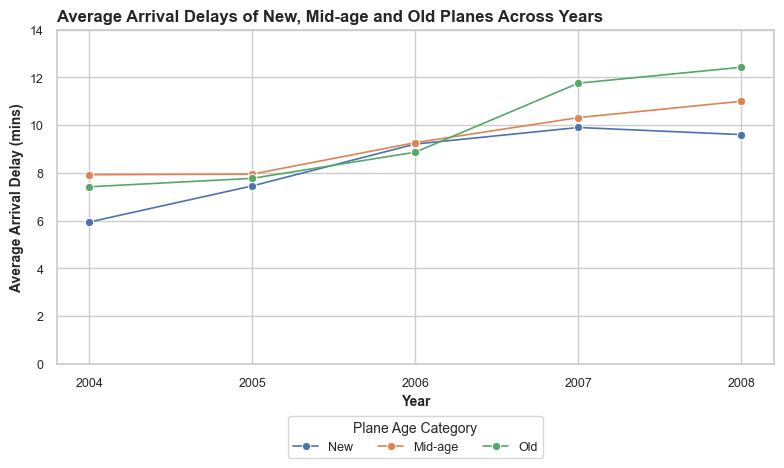

In [22]:
# Calculating average arrival delay by plane age category each year
planes_age_summary = flights_filtered.groupby(['Year', 'plane_age_category'], as_index=False, observed = False).agg(
    avg_delay=('ArrDelay', 'mean')
)

# Arranging plane_age_category again in ascending order to ensure correct arrangement after merge
planes_age_summary['plane_age_category'] = pd.Categorical(
    planes_age_summary['plane_age_category'],
    categories=['New', 'Mid-age', 'Old'],
    ordered=True
)

# Changing Year column to string type 
planes_age_summary['Year'] = planes_age_summary['Year'].astype(str)

# Creating the line chart of average arrival delays by plane age category
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

sns.lineplot(
    data=planes_age_summary,
    x='Year',
    y='avg_delay',
    hue='plane_age_category',
    marker='o',
    linewidth = 1.2,
)

plt.title("Average Arrival Delays of New, Mid-age and Old Planes Across Years", fontsize=12, weight='bold', loc='left')
plt.xlabel("Year", fontsize=10, weight='bold')
plt.ylabel("Average Arrival Delay (mins)", fontsize=10, weight='bold')
plt.ylim(0, 14)
plt.yticks(range(0, 15, 2))
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(title='Plane Age Category', title_fontsize=10, fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=3)
plt.tight_layout()
plt.show()

In [23]:
# Calculating total distance and no of flights by TailNum and Year
util_df = (
    flights_filtered
    .groupby(['TailNum', 'Year'], as_index=False)
    .agg(
        n_flights=('TailNum', 'size'),
        total_distance=('Distance', 'sum'),
        avg_delay=('ArrDelay', 'mean'),
        plane_age=('plane_age', 'first'),
        plane_age_category=('plane_age_category', 'first')
    )
)


In [24]:
# Calculating z-scores for n_flights and total_distance to standardise the values
util_df = util_df.assign(
    flights_z=(util_df['n_flights'] - util_df['n_flights'].mean()) / util_df['n_flights'].std(),
    distance_z=(util_df['total_distance'] - util_df['total_distance'].mean()) / util_df['total_distance'].std()
)


In [25]:
# Calculating utilisation score accounting for both number of flights and total distance equally weighted
util_df = util_df.assign(
    util_score=0.5 * util_df['flights_z'] + 0.5 * util_df['distance_z']
)


In [26]:
# Categorising planes into High, Medium and Low utilisation scores
util_df = util_df.assign(
    utilisation_category=np.where(
        util_df['util_score'] >= 1, 'High',
        np.where(util_df['util_score'] <= -1, 'Low', 'Medium')
    )
)

In [27]:
# Arranging utilisation_category in ascending order again to ensure correct ordering after merging
util_df['utilisation_category'] = pd.Categorical(
    util_df['utilisation_category'],
    categories=['Low', 'Medium', 'High'],
    ordered=True
)

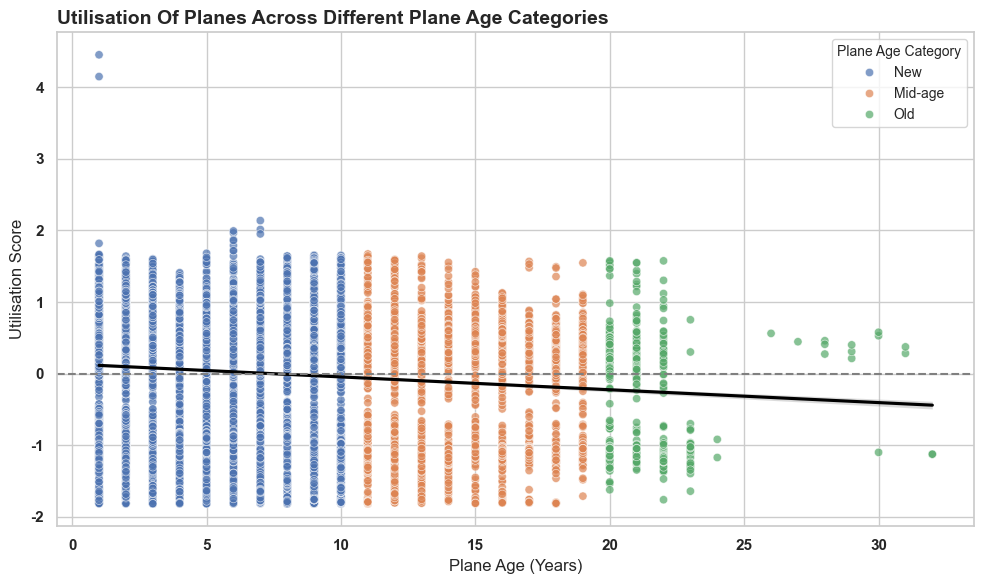

In [47]:
# Constructing a scatter plot for relationship between age of planes and their utilisation rates 
plt.figure(figsize = (10, 6))
sns.set(style = "whitegrid")

scatter = sns.scatterplot(
    data = util_df,
    x = 'plane_age',
    y = 'util_score',
    hue = 'plane_age_category',
    alpha = 0.7
)

sns.regplot(
    data = util_df,
    x = 'plane_age',
    y = 'util_score',
    scatter = False,
    ax = scatter,
    color = 'black',
    line_kws={'linestyle': 'solid'}
)

plt.axhline(y=0, linestyle='dashed', color='gray')

# Avoid scientific notation
scatter.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title("Utilisation Of Planes Across Different Plane Age Categories", fontsize=14, weight='bold', loc='left')
plt.xlabel("Plane Age (Years)")
plt.ylabel("Utilisation Score")
plt.xticks(fontsize=11, fontweight ='bold')
plt.yticks(fontsize=11, fontweight ='bold')
plt.legend(title="Plane Age Category", loc='upper right', fontsize=10, title_fontsize=10)
plt.tight_layout()
plt.show()

In [40]:
# Calculating correlation between plane_age and util_score
subset = util_df[['plane_age', 'util_score']].dropna()
r_value = subset['plane_age'].corr(subset['util_score'])
print("Correlation (R):", r_value)


Correlation (R): -0.11114856511463282


In [41]:
# Arranging plane_age_category in ascending order
util_df['plane_age_category'] = pd.Categorical(
    util_df['plane_age_category'],
    categories=['New', 'Mid-age', 'Old'],
    ordered=True
)


In [ ]:
# creating utils_to_delays df for plotting based on the different plane_age_category and utilisation_category
utils_to_delays = (
    util_df
    .groupby(['plane_age_category', 'utilisation_category'], observed=False, dropna=False)
    .agg(group_avg_delay=('avg_delay', 'mean'))
    .reset_index()
)

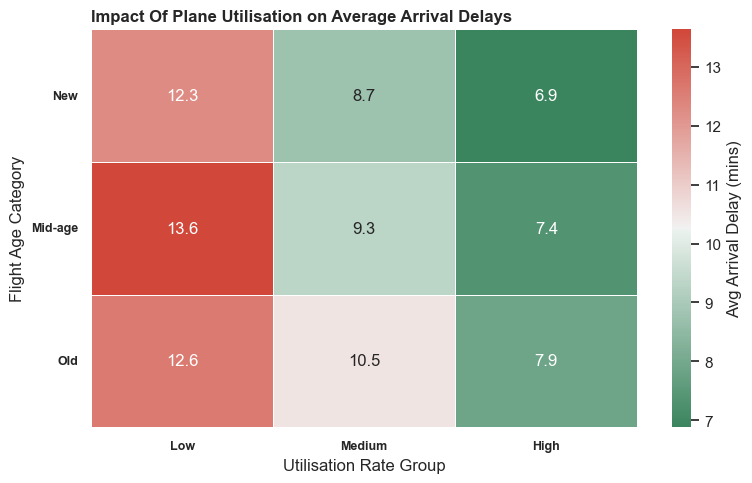

In [46]:
# Constructing heatmap for average delay by plane age category and utilisation group
heatmap_data = utils_to_delays.pivot(index = 'plane_age_category', columns = 'utilisation_category', values = 'group_avg_delay')

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.diverging_palette(145, 15, as_cmap=True),
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Arrival Delay (mins)'}
)

plt.title("Impact Of Plane Utilisation on Average Arrival Delays", fontsize=12, weight='bold', loc='left')
plt.xlabel("Utilisation Rate Group")
plt.ylabel("Flight Age Category")
plt.xticks(fontsize=9, weight='bold')
plt.yticks(fontsize=9, weight='bold', rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Importing libraries for ANOVA test and Tukey's HSD test
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### 

In [ ]:
# Performing ANOVA test to check if there are significant differences in average arrival delays across plane age categories
model = ols('avg_delay ~ C(plane_age_category)', data=util_df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                              sum_sq       df          F        PR(>F)
C(plane_age_category)    3868.849322      2.0  34.142867  1.592637e-15
Residual               947981.115927  16732.0        NaN           NaN


In [ ]:
# Performing Tukey's HSD test for pairwise comparisons between plane age categories
tukey = pairwise_tukeyhsd(
    endog=util_df['avg_delay'],
    groups=util_df['plane_age_category'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
Mid-age    New  -0.9126    0.0 -1.2498 -0.5754   True
Mid-age    Old   1.0186 0.0092  0.2067  1.8306   True
    New    Old   1.9312    0.0  1.1601  2.7023   True
-----------------------------------------------------
